**Learner Demographic Analysis**

---



## Importing Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

In [7]:
# importing datasets
users_df = pd.read_csv(r"C:\Users\anany\OneDrive\Desktop\learner_analytics\data\raw\EduPro Online Platform.xlsx - Users.csv")
teachers_df = pd.read_csv(r"C:\Users\anany\OneDrive\Desktop\learner_analytics\data\raw\EduPro Online Platform.xlsx - Teachers.csv")
courses_df = pd.read_csv(r"C:\Users\anany\OneDrive\Desktop\learner_analytics\data\raw\EduPro Online Platform.xlsx - Courses.csv")
transactions_df = pd.read_csv(r"C:\Users\anany\OneDrive\Desktop\learner_analytics\data\raw\EduPro Online Platform.xlsx - Transactions.csv")

In [8]:
users_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   UserID    3000 non-null   object
 1   UserName  3000 non-null   object
 2   Age       3000 non-null   int64 
 3   Gender    3000 non-null   object
 4   Email     3000 non-null   object
dtypes: int64(1), object(4)
memory usage: 117.3+ KB


In [9]:
teachers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TeacherID          60 non-null     object 
 1   TeacherName        60 non-null     object 
 2   Age                60 non-null     int64  
 3   Gender             60 non-null     object 
 4   Expertise          60 non-null     object 
 5   YearsOfExperience  60 non-null     int64  
 6   TeacherRating      60 non-null     float64
dtypes: float64(1), int64(2), object(4)
memory usage: 3.4+ KB


In [10]:
courses_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CourseID        60 non-null     object 
 1   CourseName      60 non-null     object 
 2   CourseCategory  60 non-null     object 
 3   CourseType      60 non-null     object 
 4   CourseLevel     60 non-null     object 
 5   CoursePrice     60 non-null     float64
 6   CourseDuration  60 non-null     float64
 7   CourseRating    60 non-null     float64
dtypes: float64(3), object(5)
memory usage: 3.9+ KB


In [11]:
transactions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   TransactionID    10000 non-null  object 
 1   UserID           10000 non-null  object 
 2   CourseID         10000 non-null  object 
 3   TransactionDate  10000 non-null  object 
 4   Amount           10000 non-null  float64
 5   PaymentMethod    10000 non-null  object 
 6   TeacherID        10000 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.0+ KB


## Data Cleaning & Preprocessing

In [12]:
# Handle Missing Values
users_df.dropna(subset=["UserID", "Age", "Gender"], inplace=True)
teachers_df.dropna(subset=["TeacherID", "Age", "Gender"], inplace=True)
courses_df.dropna(subset=["CourseID", "CourseCategory", "CourseLevel"], inplace=True)
transactions_df.dropna(subset=["TransactionID", "UserID", "CourseID"], inplace=True)

In [13]:
# Standardize Text Fields
users_df["Gender"] = users_df["Gender"].str.strip().str.title()

teachers_df["Gender"] = users_df["Gender"].str.strip().str.title()
teachers_df["TeacherName"] = teachers_df["TeacherName"].str.strip().str.title()
teachers_df["Expertise"] = teachers_df["Expertise"].str.strip().str.title()

courses_df["CourseName"] = courses_df["CourseName"].str.strip().str.title()
courses_df["CourseLevel"] = courses_df["CourseLevel"].str.strip().str.title()
courses_df["CourseCategory"] = courses_df["CourseCategory"].str.strip().str.title()

## Data Integration

In [14]:
# merging datasets
user_transactions = pd.merge(
    transactions_df,
    users_df,
    on="UserID",
    how="inner"
)

In [15]:
# full df
full_df = pd.merge(
    user_transactions,
    courses_df,
    on="CourseID",
    how="inner"
)

In [16]:
full_df.head()

,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID,UserName,Age,Gender,Email,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating
0,TT00001,U00003,CR00016,25/10/2025,0.0,PayPal,TC00040,morrisonamanda,33,Female,ganderson@yahoo.com,Digital Marketing,Marketing,Free,Intermediate,0.0,42.68,4.72
1,TT00002,U00003,CR00037,13/1/2025,0.0,PayPal,TC00040,morrisonamanda,33,Female,ganderson@yahoo.com,Scrum Essentials,Project Management,Free,Intermediate,0.0,33.93,3.45
2,TT00003,U00003,CR00019,28/3/2025,0.0,Bank Transfer,TC00040,morrisonamanda,33,Female,ganderson@yahoo.com,Content Marketing,Marketing,Free,Advanced,0.0,18.00,2.98
3,TT00004,U00004,CR00048,2/6/2025,0.0,Bank Transfer,TC00040,fthornton,23,Female,christensencatherine@outlook.com,Ai Ethics,Artificial Intelligence,Free,Beginner,0.0,42.70,3.64
4,TT00005,U00004,CR00060,10/8/2025,0.0,PayPal,TC00042,fthornton,23,Female,christensencatherine@outlook.com,Content Creation,Digital Marketing,Free,Beginner,0.0,8.95,2.14


In [17]:
full_df.shape

(10000, 18)

## Learner Demographic Analysis

### Age Band Creation

In [18]:
# Define Age Bins
bins = [0, 17, 25, 35, 45, 100]
labels = ["<18", "18–25", "26–35", "36–45", "45+"]

full_df["AgeGroup"] = pd.cut(full_df["Age"], bins=bins, labels=labels)

In [19]:
# Age Distribution
age_distribution = full_df["AgeGroup"].value_counts().sort_index()

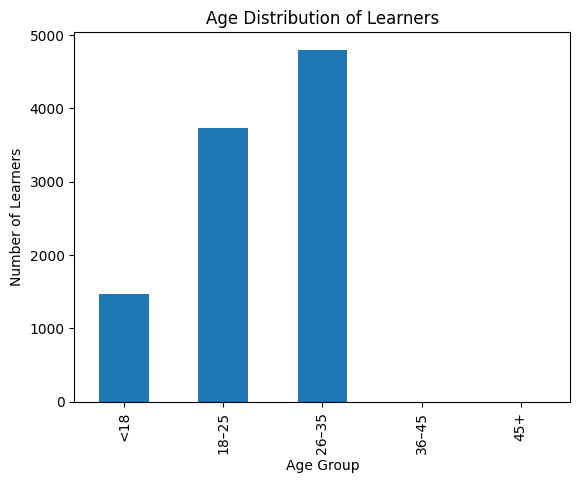

In [20]:
# Visualization
age_distribution.plot(kind="bar", title="Age Distribution of Learners")
plt.xlabel("Age Group")
plt.ylabel("Number of Learners")
plt.show()

### Gender Distribution

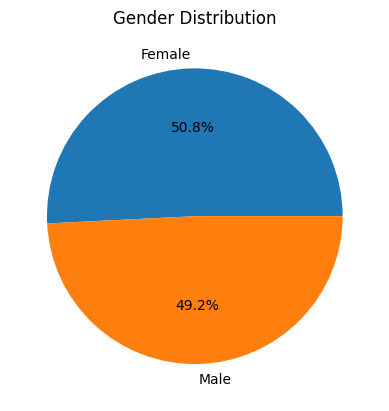

In [21]:
gender_distribution = full_df["Gender"].value_counts()

gender_distribution.plot(kind="pie", autopct="%1.1f%%", title="Gender Distribution")
plt.ylabel("")
plt.show()

## Enrollment Distribution Analysis

### Enrollments by Course Category

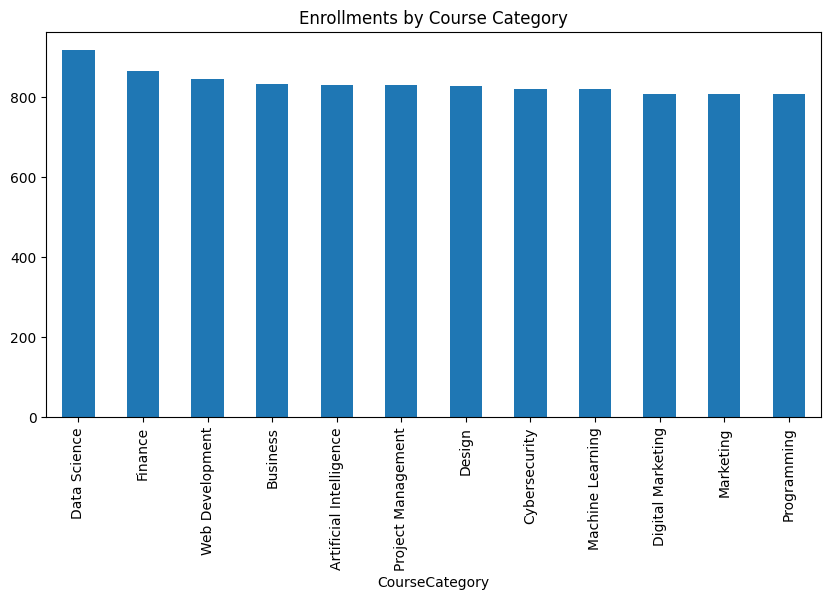

In [22]:
category_enrollments = full_df["CourseCategory"].value_counts()

category_enrollments.plot(kind="bar", figsize=(10,5), title="Enrollments by Course Category")
plt.show()

### Enrollments by Course Type

<Axes: title={'center': 'Enrollments by Course Type'}, xlabel='CourseType'>

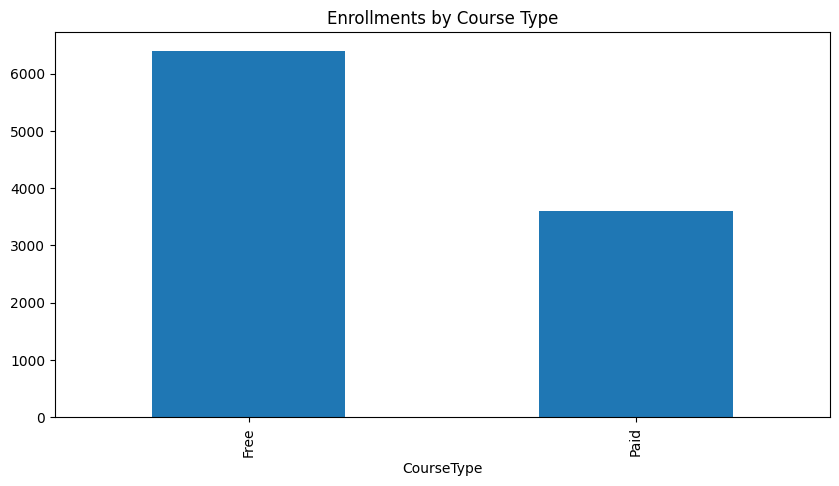

In [23]:
type_enrollments = full_df["CourseType"].value_counts()

type_enrollments.plot(kind="bar", figsize=(10,5), title="Enrollments by Course Type")

### Enrollments by Course Level

<Axes: title={'center': 'Enrollments by Course Level'}, xlabel='CourseLevel'>

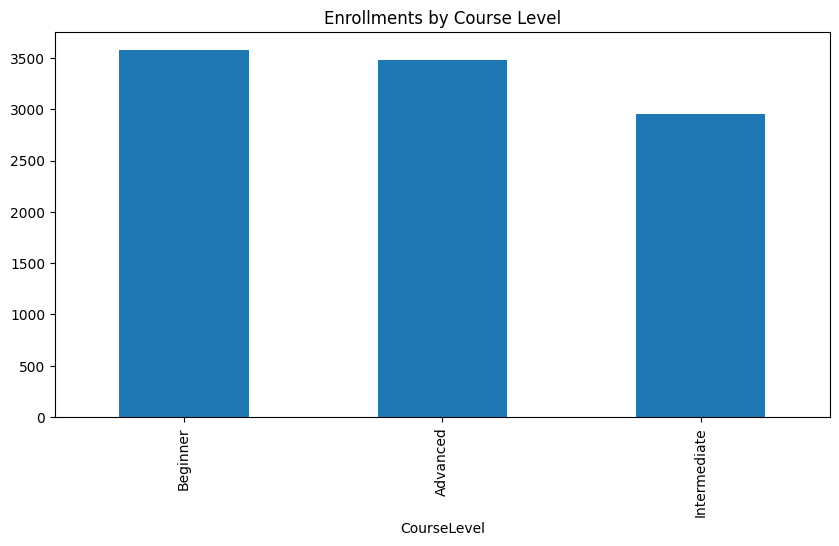

In [24]:
level_enrollments = full_df["CourseLevel"].value_counts()

level_enrollments.plot(kind="bar", figsize=(10,5), title="Enrollments by Course Level")

## Demographics × Course Preference Analysis

### Age Group vs Course Category (Heatmap)

In [25]:
# Create Pivot Table
age_category_pivot = pd.pivot_table(
    full_df,
    index="AgeGroup",
    columns="CourseCategory",
    values="CourseID",
    aggfunc="count"
)

C:\Users\anany\AppData\Local\Temp\ipykernel_6884\2436883163.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  age_category_pivot = pd.pivot_table(


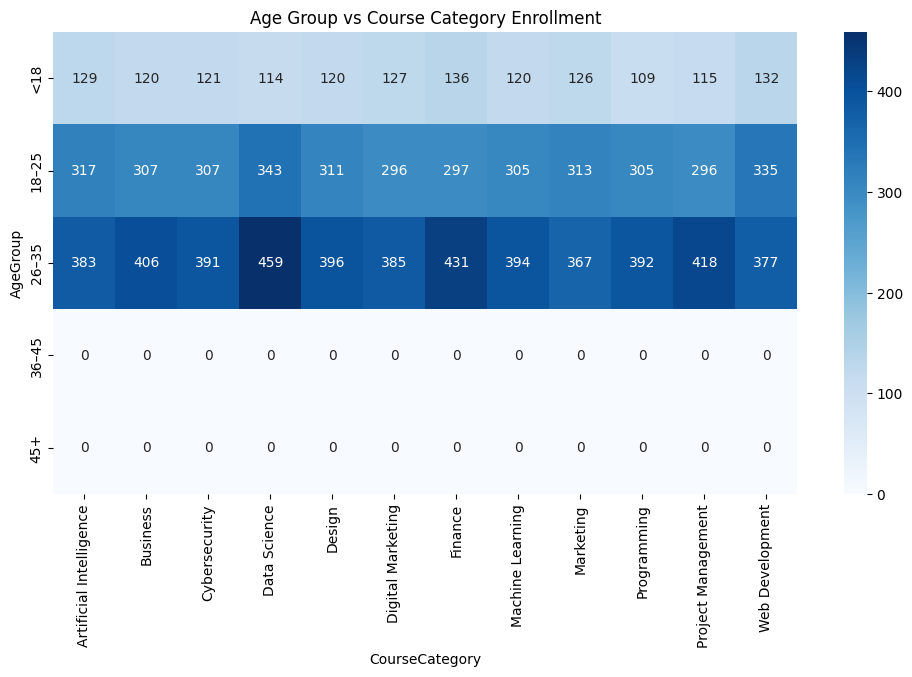

In [26]:
# Heatmap
plt.figure(figsize=(12,6))
sns.heatmap(age_category_pivot, annot=True, fmt="d", cmap="Blues")
plt.title("Age Group vs Course Category Enrollment")
plt.show()

### Gender vs Course Level

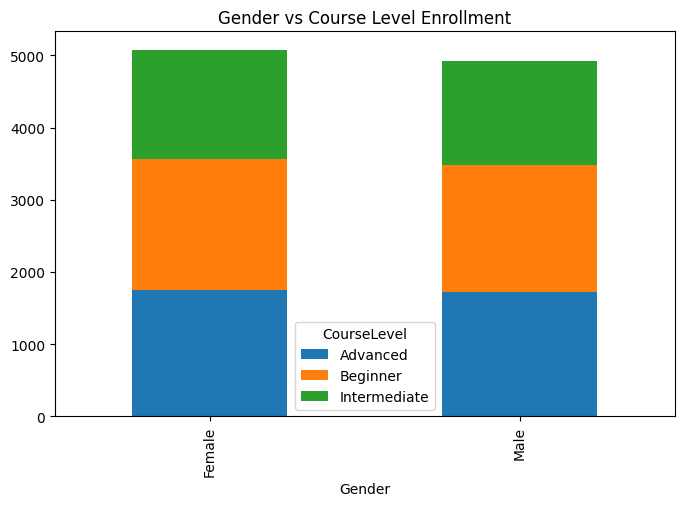

In [27]:
gender_level = pd.pivot_table(
    full_df,
    index="Gender",
    columns="CourseLevel",
    values="CourseID",
    aggfunc="count"
)

gender_level.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Gender vs Course Level Enrollment")
plt.show()

## Behavioral Insights

### Average Courses Taken per Learner

In [28]:
courses_per_user = full_df.groupby("UserID")["CourseID"].count()
avg_courses = courses_per_user.mean()

print(f"Average courses taken per learner: {avg_courses:.2f}")

Average courses taken per learner: 3.33


### Enrollment Concentration

In [29]:
courses_per_user.describe()

count    3000.000000
mean        3.333333
std         4.352149
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max        16.000000
Name: CourseID, dtype: float64

### Beginner vs Advanced Behavior

C:\Users\anany\AppData\Local\Temp\ipykernel_6884\1054309075.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  level_preference = pd.pivot_table(


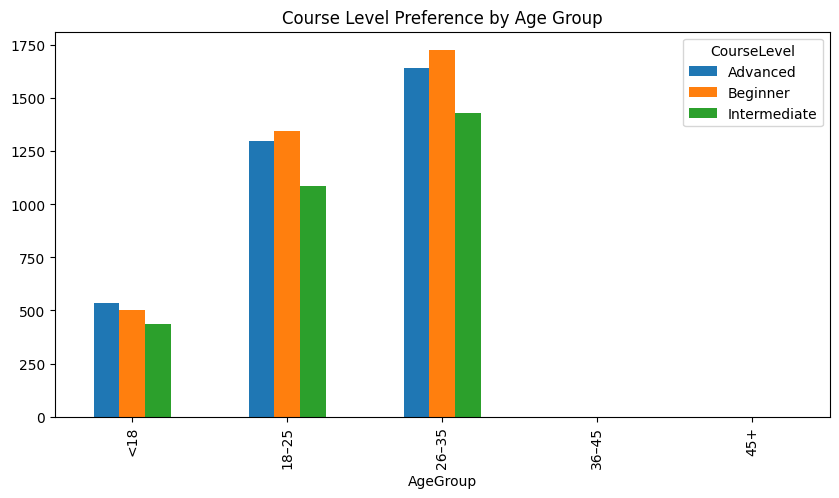

In [30]:
level_preference = pd.pivot_table(
    full_df,
    index="AgeGroup",
    columns="CourseLevel",
    values="CourseID",
    aggfunc="count"
)

level_preference.plot(kind="bar", figsize=(10,5))
plt.title("Course Level Preference by Age Group")
plt.show()

In [31]:
full_df.to_csv("../data/processed/edupro_clean_data.csv", index=False)